<a href="https://colab.research.google.com/github/AnujikaSasindi/sri-lanka-tourism-sentiment-analysis/blob/Main/Try_Again_2__Attraction_Prediction_Model_2_(Roberta).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers[torch] accelerate datasets evaluate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 107.6 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.0
    Uninstalling transformers-5.12.0:
      Successfully uninstalled transformers-5.12.0


In [26]:
import pandas as pd
import numpy as np
import torch
import re

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_excel('balanced_cleaned_dataset_1_(sentiment + attarction category).xlsx')

print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Saving balanced_cleaned_dataset_1_(sentiment + attarction category).xlsx to balanced_cleaned_dataset_1_(sentiment + attarction category).xlsx
Shape of dataset: (7164, 11)

Column names:
['Location_Name', 'Located_City', 'Location_Type', 'Title', 'Text', 'Review_Text', 'Rating', 'Sentiment', 'Cluster_Text', 'Attraction_Cluster', 'Attraction_Category']

First 5 rows:


,Location_Name,Located_City,Location_Type,Title,Text,Review_Text,Rating,Sentiment,Cluster_Text,Attraction_Cluster,Attraction_Category
0,Handunugoda Tea Estate,Ahangama,Farms,Wonderful Experience,This was our third tea factory tour during our...,Wonderful Experience This was our third tea fa...,5,Positive,Handunugoda Tea Estate Farms Wonderful Experie...,4,Tea Plantations & Factory Tours
1,Glenloch Tea Factory,Katukitula,Farms,In-TEA-resting,A worth visit for everyone who drinks tea. Gui...,In-TEA-resting A worth visit for everyone who ...,4,Positive,Glenloch Tea Factory Farms In-TEA-resting A wo...,4,Tea Plantations & Factory Tours
2,Handunugoda Tea Estate,Ahangama,Farms,"The best tea experience, great history","Hidden away in a beautiful stretch of green, t...","The best tea experience, great history Hidden ...",5,Positive,Handunugoda Tea Estate Farms The best tea expe...,4,Tea Plantations & Factory Tours
3,Bluefield Tea Gardens,Nuwara Eliya,Farms,Informative tour,We really enjoyed our tour at the Bluefield te...,Informative tour We really enjoyed our tour at...,5,Positive,Bluefield Tea Gardens Farms Informative tour W...,4,Tea Plantations & Factory Tours
4,Ceylon Tea Museum,Kandy,Museums,Under appreciated - well worth,We spend a few enjoyable hours here. It is aro...,Under appreciated - well worth We spend a few ...,4,Positive,Ceylon Tea Museum Museums Under appreciated - ...,4,Tea Plantations & Factory Tours


In [ ]:
# # Drop combined_text column
# df = df.drop(columns=['combined_text'])

# # Check columns
# print(df.columns)

# # Save updated dataset
# file_name = "dataset_with_cluster_names_(Attractions)- WITHOUT_combined_text.xlsx"

# df.to_excel(file_name, index=False)

# # Download to PC
# from google.colab import files
# files.download(file_name)

# print("Dataset saved and download started.")

Index(['Location_Name', 'Located_City', 'Location', 'Location_Type',
       'Travel_Date', 'Published_Date', 'Rating', 'Title', 'Text',
       'Sentiment_Class', 'Cluster', 'Cluster_Name'],
      dtype='object')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dataset saved and download started.


In [6]:
cols = ['Title', 'Text']

for col in cols:
    df[col] = df[col].fillna('')

df['Combined_Text'] = (
    df['Title'] + ' ' +
    df['Text']
)

cleaned_texts = []
for text in df["Combined_Text"]:
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    cleaned_texts.append(text)
df["Combined_Text"] = cleaned_texts

In [7]:
label_encoder = LabelEncoder()

df['label'] = label_encoder.fit_transform(df['Attraction_Category'])

# Save mapping
label_mapping = dict(
    zip(label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_))
)

print(label_mapping)

{'Beaches & Coastal Areas': np.int64(0), 'Gardens, Lakes & Waterfalls': np.int64(1), 'Museums & Historic Sites': np.int64(2), 'Tea Plantations & Factory Tours': np.int64(3), 'Temples & Religious Sites': np.int64(4), 'Wildlife & National Parks': np.int64(5)}


In [8]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

print(train_df.shape)
print(val_df.shape)

(5731, 13)
(1433, 13)


In [9]:
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

In [10]:
model_name = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [12]:
def tokenize_function(examples):
    return tokenizer(
        examples["Combined_Text"],
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/5731 [00:00<?, ? examples/s]

Map:   0%|          | 0/1433 [00:00<?, ? examples/s]

In [13]:
train_dataset = train_dataset.rename_column(
    "label",
    "labels"
)

val_dataset = val_dataset.rename_column(
    "label",
    "labels"
)

# Keep only needed columns
columns_to_keep = [
    'input_ids',
    'attention_mask',
    'labels'
]

train_dataset = train_dataset.remove_columns(
    [col for col in train_dataset.column_names
     if col not in columns_to_keep]
)

val_dataset = val_dataset.remove_columns(
    [col for col in val_dataset.column_names
     if col not in columns_to_keep]
)

# Torch format
train_dataset.set_format("torch")
val_dataset.set_format("torch")

# Verify
print(train_dataset.column_names)

['labels', 'input_ids', 'attention_mask']


In [14]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy
    }

In [16]:
training_args = TrainingArguments(
    output_dir="./Attraction_predict_results_RA_Roberta_(26/06/27)",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=8,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",

    logging_dir='./logs'
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [17]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    #tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics
)

In [18]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.271767,0.914864
2,0.419196,0.291127,0.926727
3,0.184700,0.341834,0.923936
4,0.184700,0.342503,0.924634
5,0.093000,0.346991,0.936497
6,0.051359,0.383564,0.930914
7,0.021988,0.378916,0.935101
8,0.021988,0.383285,0.936497


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2872, training_loss=0.13586463254142273, metrics={'train_runtime': 2046.6476, 'train_samples_per_second': 22.402, 'train_steps_per_second': 1.403, 'total_flos': 5019469701151248.0, 'train_loss': 0.13586463254142273, 'epoch': 8.0})

In [19]:
predictions = trainer.predict(val_dataset)

preds = np.argmax(
    predictions.predictions,
    axis=1
)

print(
    classification_report(
        predictions.label_ids,
        preds,
        target_names=label_encoder.classes_
    )
)

                                 precision    recall  f1-score   support

        Beaches & Coastal Areas       0.95      0.93      0.94       194
    Gardens, Lakes & Waterfalls       0.90      0.94      0.92       341
       Museums & Historic Sites       0.91      0.92      0.91       230
Tea Plantations & Factory Tours       0.98      0.97      0.98       192
      Temples & Religious Sites       0.94      0.93      0.94       238
      Wildlife & National Parks       0.97      0.93      0.95       238

                       accuracy                           0.94      1433
                      macro avg       0.94      0.94      0.94      1433
                   weighted avg       0.94      0.94      0.94      1433



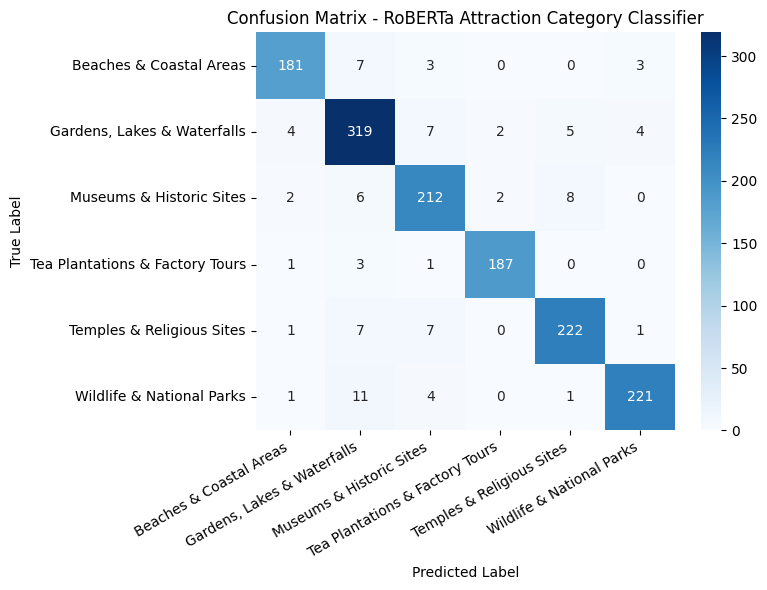

In [28]:
# Confusion Matrix

cm = confusion_matrix(
    predictions.label_ids,
    preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - RoBERTa Attraction Category Classifier")

plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()

sample_text = """
samadhi Buddha Statue
Beautiful sacred temple with historic importance.
"""

inputs = tokenizer(
    sample_text,
    return_tensors="pt",
    truncation=True,
    padding=True
)

inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

predicted_class = torch.argmax(outputs.logits, dim=1).item()

print(predicted_class)

4


In [22]:
trainer.save_model("/content/Attraction Prediction Model_2_(Roberta)_(26/06/27)")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [23]:
tokenizer.save_pretrained("/content/Attraction Prediction Model_2_(Roberta)_(26/06/27)")

('/content/Attraction Prediction Model_2_(Roberta)_(26/06/27)/tokenizer_config.json',
 '/content/Attraction Prediction Model_2_(Roberta)_(26/06/27)/tokenizer.json')

In [24]:
import shutil

shutil.make_archive(
    "/content/Attraction Prediction Model_2_(Roberta)_(26/06/27)",
    "zip",
    "/content/Attraction Prediction Model_2_(Roberta)_(26/06/27)"
)

'/content/Attraction Prediction Model_2_(Roberta)_(26/06/27).zip'

In [25]:
from google.colab import files
files.download("/content/Attraction Prediction Model_2_(Roberta)_(26/06/27).zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>